# PHQ-8 Depression Detection — WavLM Large + Bidirectional LSTM (Regression)

**Architecture**: Frozen WavLM Large (local) → layer-11 hidden states → mean-pooled 1024-dim segment features → `BiLSTM` → mean-pool over time → `Dropout` → `Linear(2·hidden, 1)`.

**Why WavLM Large?**
- WavLM improves upon HuBERT by adding masked speech **denoising** alongside masked prediction, giving it stronger speaker-characteristic modeling — crucial for depression detection (voice quality, emotion).
- The Large variant outputs **1024-dim** features across **24 transformer layers**, vs. 768-dim / 12 layers for HuBERT-base.
- Research shows intermediate blocks (≈ layer 11) of WavLM Large are particularly effective for depression-related downstream tasks.

**Approach**: WavLM weights are frozen. Features are extracted once from **transformer layer 11** and cached to disk. The biLSTM sees each participant's segments as an **ordered temporal sequence**. One PHQ-8 prediction is made per participant.

**Input**: Ordered sequence of 1024-dim WavLM features, one per 8-second window (4-second hop).

**Target**: PHQ-8 score (continuous, 0–24).

## 1. Install Dependencies

In [1]:
!pip install transformers librosa tqdm pandas numpy scipy --quiet
print("All packages ready.")

All packages ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports & Configuration

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.optim import Adam

import librosa
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from transformers import WavLMModel, Wav2Vec2FeatureExtractor

print("Imports successful.")

Imports successful.


In [3]:
# --- Paths ---
BASE_DIR      = Path("..")
DATASET_DIR   = BASE_DIR / "dataset"
PROCESSED_DIR = BASE_DIR / "processed"
META_CSV      = PROCESSED_DIR / "segment_metadata.csv"

FEATURE_CACHE  = PROCESSED_DIR / "wavlm_features.npz"   # separate cache from HuBERT
WAVLM_MODEL_DIR = Path("models/wavlm")                  # local WavLM Large weights

SAVE_DIR = BASE_DIR / "experiments" / "best_model" / "wavlm_bilstm"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --- Audio parameters (must match preprocessing pipeline) ---
TARGET_SR  = 16_000
WINDOW_SEC = 8.0
HOP_SEC    = 4.0

# --- WavLM ---
WAVLM_DIM        = 1024   # hidden_size for WavLM Large
EXTRACT_LAYER    = 11     # transformer layer to extract features from (1-indexed)
                          # research shows layer ~11 is most effective for depression
FEAT_BATCH_SIZE  = 4      # segments per forward pass (Large model is heavier than base)

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device    : {DEVICE}")
print(f"WavLM model dir : {WAVLM_MODEL_DIR.resolve()}")
print(f"Feature cache   : {FEATURE_CACHE.resolve()}")
print(f"Checkpoint dir  : {SAVE_DIR.resolve()}")

Using device    : cuda
WavLM model dir : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\experiments\models\wavlm
Feature cache   : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\processed\wavlm_features.npz
Checkpoint dir  : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\experiments\best_model\wavlm_bilstm


## 3. Load Segment Metadata

Reuse `segment_metadata.csv` from the preprocessing pipeline.
Provides train/dev/test splits and PHQ-8 labels per participant.

In [4]:
meta = pd.read_csv(META_CSV)

participant_info = (
    meta.groupby("participant_id")
    .first()[["split", "phq_score"]]
    .reset_index()
)

print(f"Total segments    : {len(meta):,}")
print(f"Total participants: {len(participant_info)}")
print("\nSplit breakdown:")
for split, grp in participant_info.groupby("split"):
    display_name = "validation" if split == "dev" else split
    print(f"  {display_name:10s}: {len(grp):3d} participants")
print(f"\nPHQ-8 range: {meta['phq_score'].min():.0f} \u2013 {meta['phq_score'].max():.0f}")

Total segments    : 21,588
Total participants: 189

Split breakdown:
  validation:  35 participants
  test      :  47 participants
  train     : 107 participants

PHQ-8 range: 0 – 23


## 4. WavLM Feature Extraction

Features are extracted **once** from transformer layer 11 of WavLM Large and cached to `processed/wavlm_features.npz`.  
On subsequent runs the cache is loaded directly — no GPU needed.

**Why layer 11?** `output_hidden_states=True` returns a tuple where index `k` corresponds to the output of the _k_-th transformer block (index 0 = CNN feature extractor). Layer 11 sits in the intermediate region shown by prior work to encode speaker identity and affective features most effectively.

In [5]:
if FEATURE_CACHE.exists():
    # ── Load from cache ──────────────────────────────────────────────────────
    print(f"Cache found — loading features from {FEATURE_CACHE.name} ...")
    cache         = np.load(FEATURE_CACHE, allow_pickle=False)
    all_feats_np  = cache["feats"]       # (N, 1024)
    all_scores_np = cache["phq_scores"]  # (N,)
    all_pids_np   = cache["pids"]        # (N,)
    all_splits_np = cache["splits"]      # (N,)  bytes

else:
    # ── Extract and save ─────────────────────────────────────────────────────
    if not WAVLM_MODEL_DIR.exists():
        raise FileNotFoundError(
            f"WavLM model directory not found at {WAVLM_MODEL_DIR.resolve()}.\n"
            "Expected: experiments/models/wavlm/config.json + pytorch_model.bin"
        )

    print(f"No cache found — extracting WavLM features from layer {EXTRACT_LAYER} ...")
    print(f"Loading model from {WAVLM_MODEL_DIR.resolve()}")

    feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(str(WAVLM_MODEL_DIR))
    wavlm = WavLMModel.from_pretrained(str(WAVLM_MODEL_DIR)).to(DEVICE)
    wavlm.eval()
    for param in wavlm.parameters():
        param.requires_grad_(False)

    print(f"WavLM Large loaded. Parameters: {sum(p.numel() for p in wavlm.parameters()):,}")

    window_samples = int(WINDOW_SEC * TARGET_SR)
    hop_samples    = int(HOP_SEC    * TARGET_SR)

    save_feats, save_scores, save_pids, save_splits = [], [], [], []

    for _, p_row in tqdm(participant_info.iterrows(),
                         total=len(participant_info),
                         desc="Participants"):

        pid       = int(p_row["participant_id"])
        split     = p_row["split"]
        phq_score = float(p_row["phq_score"])

        wav_path = DATASET_DIR / f"{pid}_P.wav"
        if not wav_path.exists():
            print(f"  [SKIP] {wav_path.name} not found")
            continue

        waveform, _ = librosa.load(wav_path, sr=TARGET_SR, mono=True)

        segments, start = [], 0
        while start + window_samples <= len(waveform):
            segments.append(waveform[start : start + window_samples])
            start += hop_samples

        if not segments:
            continue

        all_feats = []
        for i in range(0, len(segments), FEAT_BATCH_SIZE):
            batch  = segments[i : i + FEAT_BATCH_SIZE]
            inputs = feature_extractor(
                batch,
                sampling_rate=TARGET_SR,
                return_tensors="pt",
                padding=True,
            )
            input_values = inputs.input_values.to(DEVICE)
            with torch.no_grad():
                outputs = wavlm(
                    input_values,
                    output_hidden_states=True,
                )
                # hidden_states[0]  = CNN feature extractor output
                # hidden_states[k]  = output of k-th transformer block
                layer_hidden = outputs.hidden_states[EXTRACT_LAYER]  # (B, T, 1024)
                feats = layer_hidden.mean(dim=1)                      # (B, 1024)
            all_feats.append(feats.cpu().numpy())

        all_feats = np.concatenate(all_feats, axis=0)   # (n_segs, 1024)

        for feat in all_feats:
            save_feats.append(feat)
            save_scores.append(phq_score)
            save_pids.append(pid)
            save_splits.append(split.encode())

    all_feats_np  = np.array(save_feats,  dtype=np.float32)
    all_scores_np = np.array(save_scores, dtype=np.float32)
    all_pids_np   = np.array(save_pids,   dtype=np.int32)
    all_splits_np = np.array(save_splits)

    np.savez(
        FEATURE_CACHE,
        feats      = all_feats_np,
        phq_scores = all_scores_np,
        pids       = all_pids_np,
        splits     = all_splits_np,
    )
    print(f"\nDone. {len(all_feats_np):,} feature vectors extracted and cached to "
          f"{FEATURE_CACHE.name}.")

    del wavlm, feature_extractor
    torch.cuda.empty_cache()

# ── Group by participant, preserving segment order ────────────────────────────
in_memory = {
    "train": defaultdict(lambda: {"feats": [], "label": None}),
    "dev":   defaultdict(lambda: {"feats": [], "label": None}),
    "test":  defaultdict(lambda: {"feats": [], "label": None}),
}

for feat, score, pid, split_b in zip(all_feats_np, all_scores_np,
                                      all_pids_np, all_splits_np):
    split = split_b.decode()
    pid   = int(pid)
    in_memory[split][pid]["feats"].append(feat)
    in_memory[split][pid]["label"] = float(score)

splits_list = {
    s: list(in_memory[s].items()) for s in ("train", "dev", "test")
}

print(f"\nFeature shape: {all_feats_np.shape[1]}-dim  (WavLM Large layer {EXTRACT_LAYER})")
for s, name in [("train", "train"), ("dev", "validation"), ("test", "test")]:
    n_segs = sum(len(d["feats"]) for _, d in splits_list[s])
    print(f"  {name:10s}: {len(splits_list[s]):3d} participants, {n_segs:,} segments")

Cache found — loading features from wavlm_features.npz ...

Feature shape: 1024-dim  (WavLM Large layer 11)
  train     : 107 participants, 11,362 segments
  validation:  35 participants, 4,322 segments
  test      :  47 participants, 5,904 segments


## 5. Training Configuration

In [6]:
# --- Model hyper-parameters ---
LSTM_HIDDEN_DIM  = 256   # per direction; output is 2*256 = 512
LSTM_NUM_LAYERS  = 2
DROPOUT          = 0.5

# --- Training hyper-parameters ---
PARTICIPANT_BATCH_SIZE  = 8
NUM_EPOCHS              = 500
LEARNING_RATE           = 1e-4
WEIGHT_DECAY            = 1e-3
EARLY_STOPPING_PATIENCE = 50
CHECKPOINT_FREQ         = 10
GRAD_CLIP_NORM          = 1.0

print("Training configuration set.")
print(f"  Input dim              : {WAVLM_DIM}  (WavLM Large)")
print(f"  LSTM hidden dim        : {LSTM_HIDDEN_DIM} (x2 bidirectional = {2*LSTM_HIDDEN_DIM})")
print(f"  LSTM layers            : {LSTM_NUM_LAYERS}")
print(f"  Dropout                : {DROPOUT}")
print(f"  Participant batch size : {PARTICIPANT_BATCH_SIZE}")
print(f"  Epochs                 : {NUM_EPOCHS}")
print(f"  Learning rate          : {LEARNING_RATE}")
print(f"  Weight decay           : {WEIGHT_DECAY}")
print(f"  Early stopping         : {EARLY_STOPPING_PATIENCE} epochs")
print(f"  Grad clip norm         : {GRAD_CLIP_NORM}")

Training configuration set.
  Input dim              : 1024  (WavLM Large)
  LSTM hidden dim        : 256 (x2 bidirectional = 512)
  LSTM layers            : 2
  Dropout                : 0.5
  Participant batch size : 8
  Epochs                 : 500
  Learning rate          : 0.0001
  Weight decay           : 0.001
  Early stopping         : 50 epochs
  Grad clip norm         : 1.0


## 6. Model — WavLM BiLSTM Regressor

In [7]:
class WavLMBiLSTM(nn.Module):
    """
    Bidirectional LSTM regressor on top of frozen WavLM Large features.

    Input  : (T, 1024)  — ordered sequence of segment features for one participant
    Output : scalar     — predicted PHQ-8 score

    Processing:
        (T, 1024)
        → unsqueeze(0) → (1, T, 1024)
        → BiLSTM       → (1, T, 2*hidden_dim)
        → attention pooling over T  → (1, 2*hidden_dim)
        → Dropout + Linear(2*hidden_dim, 1)
        → scalar
    """
    def __init__(self,
                 input_dim:  int   = WAVLM_DIM,
                 hidden_dim: int   = LSTM_HIDDEN_DIM,
                 num_layers: int   = LSTM_NUM_LAYERS,
                 dropout:    float = DROPOUT):
        super(WavLMBiLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size    = input_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0,
        )
        self.attention = nn.Linear(2 * hidden_dim, 1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(2 * hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (T, 1024)
        x          = x.unsqueeze(0)                    # (1, T, 1024)
        out, _     = self.lstm(x)                      # (1, T, 2*hidden_dim)
        attn       = self.attention(out)               # (1, T, 1)
        attn       = torch.softmax(attn, dim=1)        # (1, T, 1)  — weights sum to 1 over T
        pooled     = (out * attn).sum(dim=1)           # (1, 2*hidden_dim)
        return self.head(pooled).squeeze()             # scalar


model = WavLMBiLSTM().to(DEVICE)

with torch.no_grad():
    dummy = torch.zeros(10, WAVLM_DIM, device=DEVICE)   # 10 segments
    out   = model(dummy)
    print(f"Output shape (10 segments): {out.shape}  (expected: torch.Size([]))")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Output shape (10 segments): torch.Size([])  (expected: torch.Size([]))
Trainable parameters: 4,203,522


## 7. Training Loop

In [8]:
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {"train_loss": [], "val_loss": [], "val_rmse": []}
best_val_loss     = float("inf")
epochs_no_improve = 0

train_participants = splits_list["train"]
print(f"Training on {len(train_participants)} participants.")


def train_epoch():
    """
    Participant-level training pass.
    Each participant's segments are fed as an ordered sequence to the biLSTM.
    One prediction per participant, MSE against participant label.
    Gradients accumulated over PARTICIPANT_BATCH_SIZE participants per update.
    """
    model.train()
    idx     = torch.randperm(len(train_participants)).tolist()
    batches = [idx[i : i + PARTICIPANT_BATCH_SIZE]
               for i in range(0, len(idx), PARTICIPANT_BATCH_SIZE)]

    total_loss, n = 0.0, 0

    for batch in batches:
        optimizer.zero_grad()
        batch_size = len(batch)

        for i in batch:
            _, data = train_participants[i]
            feats = torch.tensor(
                np.array(data["feats"]), dtype=torch.float32, device=DEVICE
            )                                                    # (T, 1024)
            label = torch.tensor(
                data["label"], dtype=torch.float32, device=DEVICE
            )                                                    # scalar

            pred = model(feats)                                  # scalar
            loss = criterion(pred, label) / batch_size
            loss.backward()

            total_loss += loss.item() * batch_size
            n          += 1

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

    return total_loss / n


def evaluate(split: str):
    """
    Participant-level evaluation.
    Each participant's segments are fed as a sequence; one prediction is made.
    """
    model.eval()
    records = []
    with torch.no_grad():
        for pid, data in splits_list[split]:
            feats = torch.tensor(
                np.array(data["feats"]), dtype=torch.float32, device=DEVICE
            )
            pred  = model(feats).item()
            records.append((pid, pred, data["label"]))

    df   = pd.DataFrame(records, columns=["participant_id", "pred", "label"])
    mse  = float(np.mean((df["pred"].values - df["label"].values) ** 2))
    rmse = mse ** 0.5
    return mse, rmse, df


for epoch in range(1, NUM_EPOCHS + 1):

    train_mse            = train_epoch()
    val_mse, val_rmse, _ = evaluate("dev")

    history["train_loss"].append(train_mse)
    history["val_loss"].append(val_mse)
    history["val_rmse"].append(val_rmse)

    print(f"Epoch [{epoch:3d}/{NUM_EPOCHS}]  "
          f"Train MSE: {train_mse:.4f}  "
          f"Val MSE: {val_mse:.4f}  "
          f"Val RMSE: {val_rmse:.4f}")

    if epoch % CHECKPOINT_FREQ == 0:
        ckpt_path = SAVE_DIR / f"epoch{epoch}_WavLM_biLSTM.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_mse":            train_mse,
            "val_mse":              val_mse,
        }, ckpt_path)
        print(f"  Checkpoint saved \u2192 {ckpt_path.name}")

    if val_mse < best_val_loss:
        best_val_loss     = val_mse
        epochs_no_improve = 0
        best_path = SAVE_DIR / "WavLM_biLSTM_best.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_mse":              val_mse,
            "val_rmse":             val_rmse,
        }, best_path)
        print(f"  Best model saved \u2192 {best_path.name}  (val MSE {val_mse:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\n  Early stopping triggered \u2014 no improvement for "
                  f"{EARLY_STOPPING_PATIENCE} epochs.")
            break

print("\nTraining complete.")
print(f"Best validation MSE  : {best_val_loss:.4f}")
print(f"Best validation RMSE : {best_val_loss ** 0.5:.4f}  PHQ-8 points")

Training on 107 participants.
Epoch [  1/500]  Train MSE: 59.4481  Val MSE: 68.3193  Val RMSE: 8.2655
  Best model saved → WavLM_biLSTM_best.pth  (val MSE 68.3193)
Epoch [  2/500]  Train MSE: 42.7377  Val MSE: 49.9412  Val RMSE: 7.0669
  Best model saved → WavLM_biLSTM_best.pth  (val MSE 49.9412)
Epoch [  3/500]  Train MSE: 30.9120  Val MSE: 43.5062  Val RMSE: 6.5959
  Best model saved → WavLM_biLSTM_best.pth  (val MSE 43.5062)
Epoch [  4/500]  Train MSE: 29.9577  Val MSE: 42.2728  Val RMSE: 6.5018
  Best model saved → WavLM_biLSTM_best.pth  (val MSE 42.2728)
Epoch [  5/500]  Train MSE: 29.5773  Val MSE: 42.4948  Val RMSE: 6.5188
Epoch [  6/500]  Train MSE: 28.9749  Val MSE: 42.2256  Val RMSE: 6.4981
  Best model saved → WavLM_biLSTM_best.pth  (val MSE 42.2256)
Epoch [  7/500]  Train MSE: 28.9853  Val MSE: 41.6846  Val RMSE: 6.4564
  Best model saved → WavLM_biLSTM_best.pth  (val MSE 41.6846)
Epoch [  8/500]  Train MSE: 26.8074  Val MSE: 40.5576  Val RMSE: 6.3685
  Best model saved → W

## 8. Training Curves

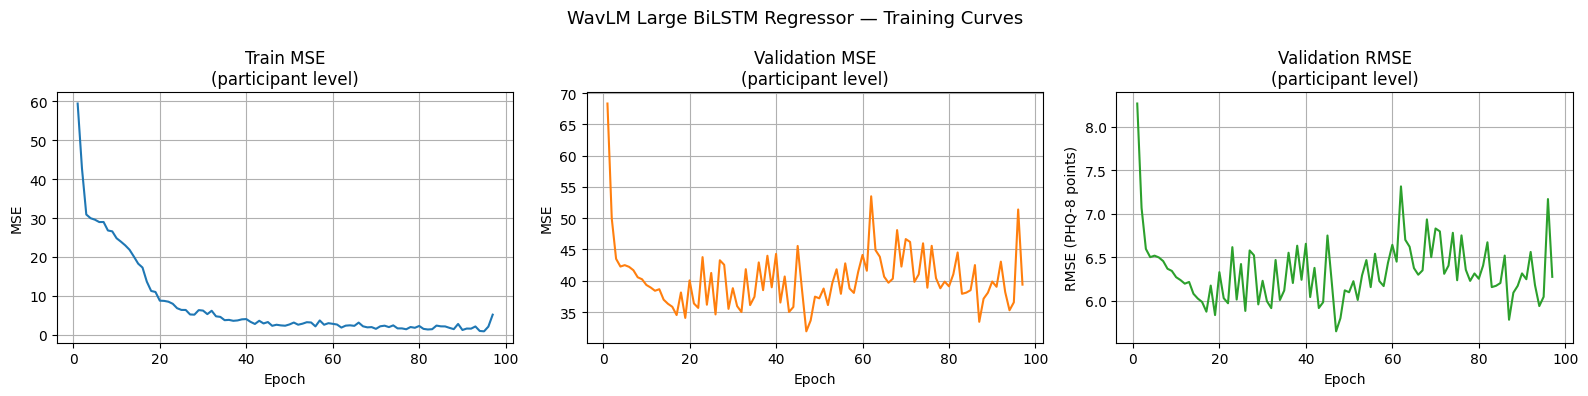

In [9]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_ran, history["train_loss"], color="tab:blue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Train MSE\n(participant level)")
axes[0].grid(True)

axes[1].plot(epochs_ran, history["val_loss"], color="tab:orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")
axes[1].set_title("Validation MSE\n(participant level)")
axes[1].grid(True)

axes[2].plot(epochs_ran, history["val_rmse"], color="tab:green")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("RMSE (PHQ-8 points)")
axes[2].set_title("Validation RMSE\n(participant level)")
axes[2].grid(True)

plt.suptitle("WavLM Large BiLSTM Regressor \u2014 Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Evaluation on Test Set

Loads the best checkpoint and reports participant-level MSE, RMSE, MAE, and Pearson r.

In [10]:
best_ckpt = torch.load(
    SAVE_DIR / "WavLM_biLSTM_best.pth",
    map_location=DEVICE,
    weights_only=True,
)
model.load_state_dict(best_ckpt["model_state_dict"])
print(f"Loaded best model from epoch {best_ckpt['epoch']}  "
      f"(val MSE {best_ckpt['val_mse']:.4f})")

_, _, test_df = evaluate("test")

all_preds  = test_df["pred"].values
all_labels = test_df["label"].values

test_mse  = float(np.mean((all_preds - all_labels) ** 2))
test_rmse = test_mse ** 0.5
test_mae  = float(np.mean(np.abs(all_preds - all_labels)))
test_r, _ = pearsonr(all_preds, all_labels)

print(f"  Participants evaluated: {len(test_df)}")
print("\n\u2500\u2500 Test-set results (participant level) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500")
print(f"  MSE       : {test_mse:.4f}")
print(f"  RMSE      : {test_rmse:.4f}  PHQ-8 points")
print(f"  MAE       : {test_mae:.4f}  PHQ-8 points")
print(f"  Pearson r : {test_r:.4f}")

Loaded best model from epoch 47  (val MSE 31.9209)
  Participants evaluated: 47

── Test-set results (participant level) ───────────
  MSE       : 46.7137
  RMSE      : 6.8347  PHQ-8 points
  MAE       : 5.4638  PHQ-8 points
  Pearson r : 0.1558


## 10. Prediction Distribution

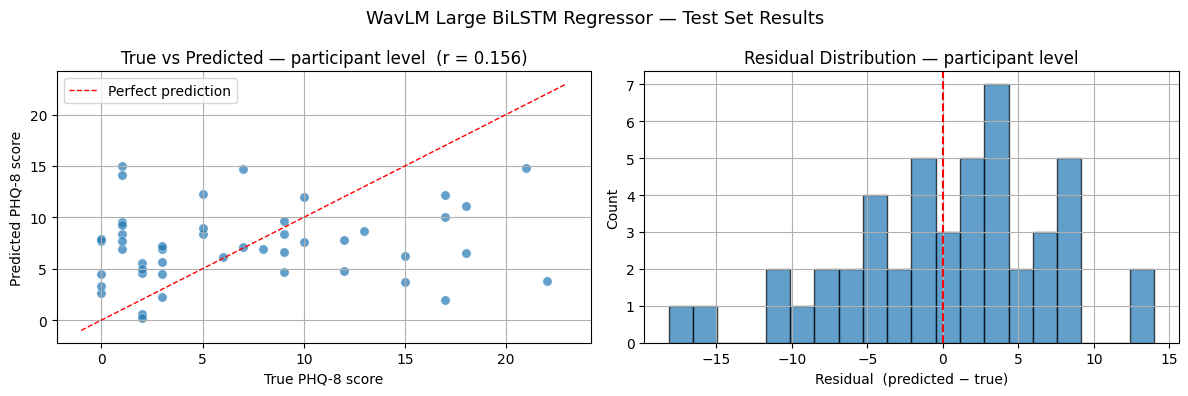

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(all_labels, all_preds, alpha=0.7, s=45,
                edgecolors="white", linewidths=0.4)
lo = min(all_labels.min(), all_preds.min()) - 1
hi = max(all_labels.max(), all_preds.max()) + 1
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("True PHQ-8 score")
axes[0].set_ylabel("Predicted PHQ-8 score")
axes[0].set_title(f"True vs Predicted \u2014 participant level  (r = {test_r:.3f})")
axes[0].legend()
axes[0].grid(True)

residuals = all_preds - all_labels
axes[1].hist(residuals, bins=20, edgecolor="k", alpha=0.7)
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Residual  (predicted \u2212 true)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution \u2014 participant level")
axes[1].grid(True)

plt.suptitle("WavLM Large BiLSTM Regressor \u2014 Test Set Results", fontsize=13)
plt.tight_layout()
plt.show()